# K-mean clustering model

## Data preprocessing

### Importing the libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset

In [26]:
dataset = pd.read_csv("Mall_Customers.csv")
X = dataset.iloc[:, [3, 4]].values
X[:5, :]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

In [27]:
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Diplaying the dataset on plotly

In [28]:
import plotly.express as px
px.scatter(dataset, x="Spending Score (1-100)", y="Annual Income (k$)", color="Genre", size="Age")

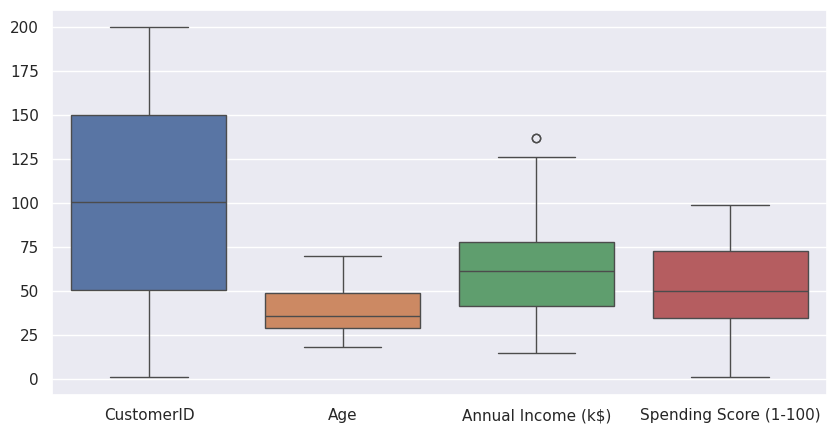

In [29]:
import seaborn as sns

sns.set_theme()

plt.subplots(figsize=(10, 5))
sns.boxplot(data=dataset);
plt.show()

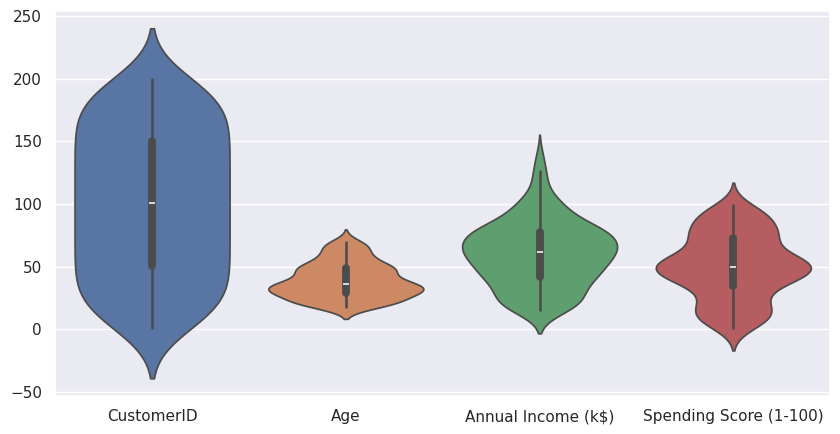

In [30]:
plt.subplots(figsize=(10, 5))
sns.violinplot(data=dataset)
plt.show()

## Using elbow method to find the optimal number of cluster

In [31]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

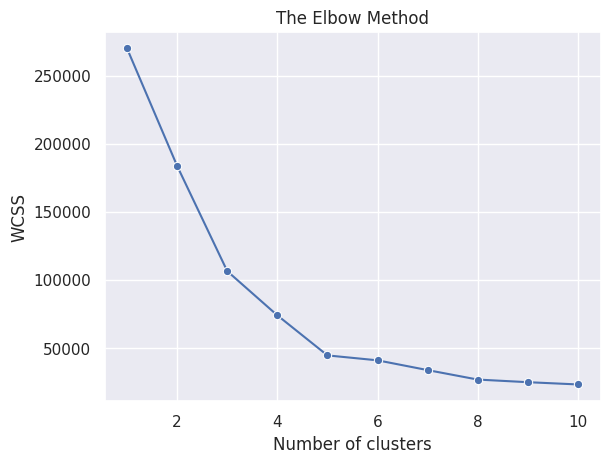

In [32]:
import seaborn as sns

sns.lineplot(x=range(1, 11), y=wcss, marker="o")
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

## Training K-Means model on the dataset

In [33]:
kmeans_model = KMeans(n_clusters=5, init="k-means++", random_state = 42)
y_kmeans = kmeans_model.fit_predict(X)

In [34]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Visualizing Clusters

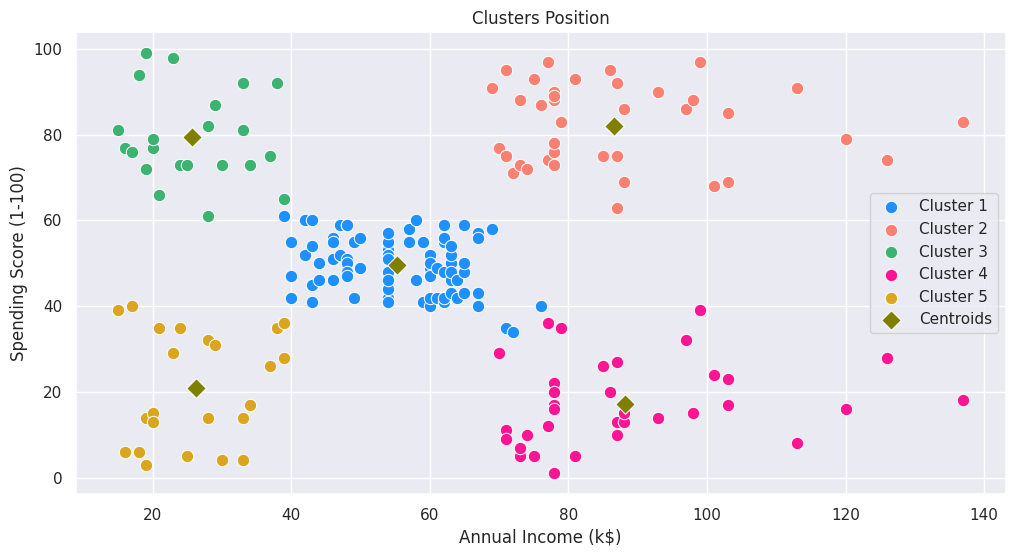

In [35]:
plt.subplots(figsize=(12, 6))
sns.scatterplot(x=X[y_kmeans == 0, 0], y=X[y_kmeans == 0, 1], s=80, c='dodgerblue', label='Cluster 1')
sns.scatterplot(x=X[y_kmeans == 1, 0], y=X[y_kmeans == 1, 1], s=80, c='salmon', label='Cluster 2')
sns.scatterplot(x=X[y_kmeans == 2, 0], y=X[y_kmeans == 2, 1], s=80, c='mediumseagreen', label='Cluster 3')
sns.scatterplot(x=X[y_kmeans == 3, 0], y=X[y_kmeans == 3, 1], s=80, c='deeppink', label='Cluster 4')
sns.scatterplot(x=X[y_kmeans == 4, 0], y=X[y_kmeans == 4, 1], s=80, c='goldenrod', label='Cluster 5')
sns.scatterplot(x=kmeans_model.cluster_centers_[:, 0], y=kmeans_model.cluster_centers_[:, 1], marker='D', s=100, c='olive', label="Centroids")
plt.title("Clusters Position")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()